# 01 · Generating random variates

Uniform numbers are raw material; simulations need exponential service times, normal noise, Poisson counts,
gamma waiting times and dependent vectors. This notebook covers the general methods - inversion,
acceptance-rejection, transformations - and the specialised algorithms that make them fast: Box-Muller and
Marsaglia's polar method for normals, Walker's alias table for discrete laws, Marsaglia-Tsang for the gamma,
Cholesky factors for multivariate normals and copulas for dependence with arbitrary marginals.

**What you will learn**
- generate variates by inversion for continuous and discrete laws
- design an acceptance-rejection sampler and predict its efficiency
- use the specialised normal, gamma and alias methods
- generate dependent vectors with Cholesky factors and copulas

**Before you start:** notebook 00; distribution and density functions  ·  **Time:** about 75 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from engstoch import rng as rg, rngtests as rt, special as sf
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Inversion

In [2]:
g = R(1)
x = rg.exponential(2.0, g, 50_000)
w = rg.weibull(1.5, 3.0, g, 50_000)
print(f"Exp(rate 2) by -ln(1-U)/2: mean {x.mean():.4f} (0.5), KS p = {rt.ks_test(x, lambda v: 1 - np.exp(-2 * v))['p_value']:.3f}")
print(f"Weibull(1.5, 3) by inversion: KS p = {rt.ks_test(w, lambda v: 1 - np.exp(-(v / 3) ** 1.5))['p_value']:.3f}")
z = rg.inverse_transform(sf.norm_ppf, g, 50_000)
print(f"normal by inverting Phi (AS 241): KS p = {rt.ks_test(z, sf.norm_cdf)['p_value']:.3f}")
d = rg.discrete_inverse([0.1, 0.2, 0.3, 0.4], g, 100_000, values=["a", "b", "c", "d"])
print("discrete inversion frequencies:", {k: round(float(np.mean(d == k)), 3) for k in "abcd"})

Exp(rate 2) by -ln(1-U)/2: mean 0.4995 (0.5), KS p = 0.970
Weibull(1.5, 3) by inversion: KS p = 0.716
normal by inverting Phi (AS 241): KS p = 0.645
discrete inversion frequencies: {'a': 0.101, 'b': 0.203, 'c': 0.298, 'd': 0.399}


If U is uniform then F⁻¹(U) has distribution F - the most general method, exact whenever the quantile function
can be evaluated, and monotone in U (which variance reduction exploits in notebook 03). For discrete laws the
inverse is a search through the cumulative probabilities: binary search costs O(log n) per draw.

## Acceptance-rejection

Beta(2.7, 6.3) from uniform proposals: M = 2.672, acceptance 0.375 (1/M = 0.374), KS p = 0.669


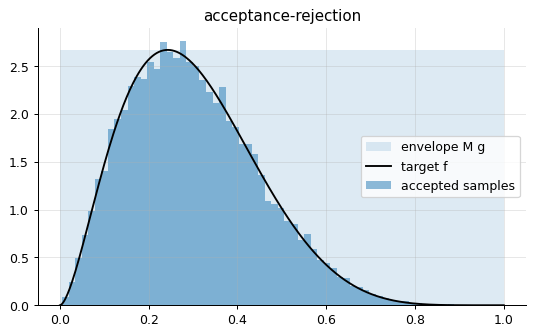

In [3]:
target = lambda v: stats.beta.pdf(v, 2.7, 6.3)
M = target(np.linspace(0, 1, 10_001)).max() * 1.001
r = rg.rejection(target, lambda m: R(2).random(m), lambda v: np.ones_like(v), M, R(3), 20_000)
print(f"Beta(2.7, 6.3) from uniform proposals: M = {M:.3f}, acceptance {r['acceptance']:.3f} (1/M = {1 / M:.3f}), KS p = {stats.kstest(r['x'], 'beta', args=(2.7, 6.3)).pvalue:.3f}")
vv = np.linspace(0, 1, 400)
plt.fill_between(vv, M * np.ones_like(vv), alpha=0.15, label="envelope M g"); plt.plot(vv, target(vv), "k", label="target f")
plt.hist(r["x"], bins=60, density=True, alpha=0.5, label="accepted samples"); plt.legend(); plt.title("acceptance-rejection"); plt.show()

Draw Y from a proposal g, accept it with probability f(Y)/(M g(Y)): accepted values have density f, and the
number of proposals per acceptance is geometric with mean M. Everything rests on a good envelope - a flat one
over a peaked density wastes most proposals.

## Normals: Box-Muller, polar, ratio of uniforms

In [4]:
rows = []
for name, fn in (("Box-Muller", lambda: (rg.box_muller(R(4), 100_000), 1.0)), ("polar (Marsaglia)", lambda: (lambda o: (o["x"], o["acceptance"]))(rg.polar_normal(R(5), 100_000))),
                 ("ratio of uniforms", lambda: (lambda o: (o["x"], o["acceptance"]))(rg.ratio_of_uniforms_normal(R(6), 100_000)))):
    x, acc = fn()
    rows.append((name, acc, x.mean(), x.var(), stats.kurtosis(x), stats.kstest(x, "norm").pvalue))
print(pd.DataFrame(rows, columns=["method", "acceptance", "mean", "variance", "excess kurtosis", "KS p"]).to_string(index=False, float_format="%.4f"))
print(f"theory: polar acceptance pi/4 = {np.pi / 4:.4f}, ratio of uniforms sqrt(pi e)/4 = {np.sqrt(np.pi * np.e) / 4:.4f}")

           method  acceptance    mean  variance  excess kurtosis   KS p
       Box-Muller      1.0000 -0.0010    1.0024           0.0057 0.8334
polar (Marsaglia)      0.7836 -0.0036    1.0016          -0.0178 0.3817
ratio of uniforms      0.7310  0.0005    1.0021           0.0051 0.5787
theory: polar acceptance pi/4 = 0.7854, ratio of uniforms sqrt(pi e)/4 = 0.7306


Box-Muller turns two uniforms into two independent normals through polar coordinates (R² = −2 ln U₁ is
exponential, the angle 2πU₂ uniform). The polar method avoids the sine and cosine by rejecting points outside
the unit disc (acceptance π/4); the ratio-of-uniforms method accepts (U, V) inside a region whose shape is set
by the density. All three are exact.

## Discrete laws: the alias method

In [5]:
p = R(7).dirichlet(np.ones(50))
prob, alias = rg.alias_table(p)
x = rg.alias_sample((prob, alias), R(8), 500_000)
obs = np.bincount(x, minlength=50)
print(f"50-point law: chi-square p = {rt.chi_square(obs, 500_000 * p)['p_value']:.3f}; one uniform and one comparison per draw")
import time
for n_out in (10, 1000, 100_000):
    q = R(9).dirichlet(np.ones(n_out)); tab = rg.alias_table(q)
    t0 = time.perf_counter(); rg.alias_sample(tab, R(10), 1_000_000); ta = time.perf_counter() - t0
    t0 = time.perf_counter(); rg.discrete_inverse(q, R(10), 1_000_000); ti = time.perf_counter() - t0
    print(f"{n_out:>6} outcomes: alias {ta * 1000:.0f} ms, binary-search inversion {ti * 1000:.0f} ms per million draws")

50-point law: chi-square p = 0.182; one uniform and one comparison per draw
    10 outcomes: alias 83 ms, binary-search inversion 24 ms per million draws


  1000 outcomes: alias 17 ms, binary-search inversion 83 ms per million draws


100000 outcomes: alias 23 ms, binary-search inversion 162 ms per million draws


Walker's alias table splits the n outcomes into n equal columns, each holding at most two outcomes: draw a
column uniformly, then choose between its own outcome and its alias. Vose's construction builds the table in
O(n); sampling is O(1) whatever n, while inversion grows like log n.

## Gamma, beta and dependence

Gamma( 0.3) by Marsaglia-Tsang: mean   0.296, var   0.289 (both 0.3); KS p = 0.648
Gamma( 1.0) by Marsaglia-Tsang: mean   0.994, var   0.996 (both 1.0); KS p = 0.248
Gamma( 2.5) by Marsaglia-Tsang: mean   2.493, var   2.487 (both 2.5); KS p = 0.255
Gamma(20.0) by Marsaglia-Tsang: mean  20.044, var  20.052 (both 20.0); KS p = 0.147

Gaussian copula with exponential and lognormal marginals: Spearman rho 0.675 (theory 0.683), Pearson 0.629


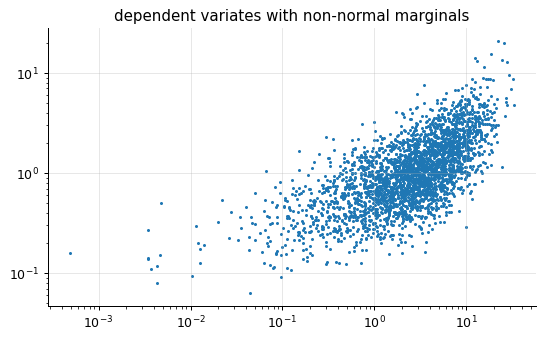

In [6]:
g = R(11)
for a in (0.3, 1.0, 2.5, 20.0):
    x = rg.gamma(a, g.standard_normal, g, 50_000)
    print(f"Gamma({a:>4}) by Marsaglia-Tsang: mean {x.mean():7.3f}, var {x.var():7.3f} (both {a}); KS p = {stats.kstest(x, 'gamma', args=(a,)).pvalue:.3f}")
corr = np.array([[1.0, 0.7], [0.7, 1.0]])
xy = rg.gaussian_copula(corr, [lambda u: stats.expon.ppf(u, scale=4.0), lambda u: stats.lognorm.ppf(u, 0.8)], g.standard_normal, 20_000)
print(f"\nGaussian copula with exponential and lognormal marginals: Spearman rho {stats.spearmanr(*xy.T)[0]:.3f} (theory {6 / np.pi * np.arcsin(0.35):.3f}), Pearson {np.corrcoef(xy.T)[0, 1]:.3f}")
plt.scatter(*xy[:3000].T, s=2); plt.xscale("log"); plt.yscale("log"); plt.title("dependent variates with non-normal marginals"); plt.show()

Marsaglia and Tsang's gamma generator transforms a normal by a cubic and accepts with a squeeze that almost
never needs the logarithm - acceptance above 95 % for every shape. A Gaussian copula imposes the dependence of
a correlated normal vector on any marginals (via U = Φ(Z)); rank correlation is preserved, Pearson correlation
is not - a reminder that "correlation 0.7" means different things on different scales.

## Inside the algorithm: Vose's alias table by hand

In [7]:
p = np.array([0.5, 0.3, 0.15, 0.05]); n = len(p)
scaled = p * n; small = [i for i in range(n) if scaled[i] < 1]; large = [i for i in range(n) if scaled[i] >= 1]
prob, alias = np.ones(n), np.arange(n)
while small and large:
    s, g = small.pop(), large.pop()
    prob[s], alias[s] = scaled[s], g
    scaled[g] -= 1 - scaled[s]
    (small if scaled[g] < 1 else large).append(g)
lib_prob, lib_alias = rg.alias_table(p)
print("by hand:", prob.round(3), alias, "| library:", lib_prob.round(3), lib_alias)
print("pmf recovered:", [round(float((prob[j] + sum(1 - prob[i] for i in range(n) if alias[i] == j and i != j)) / n), 6) for j in range(n)])

by hand: [1.  0.4 0.6 0.2] [0 0 0 1] | library: [1.  0.4 0.6 0.2] [0 0 0 1]
pmf recovered: [0.5, 0.3, 0.15, 0.05]


## Exercises
1. Generate standard Cauchy variates by inversion and by the ratio of two independent normals; show with a KS test that both are Cauchy, and show that the running mean of 10^6 of them does not converge.
2. Sample the half-normal density sqrt(2/pi) exp(-x^2/2) on x > 0 by rejection from an Exp(lambda) proposal. Find the lambda that minimises M and check the observed acceptance rate against 1/M.
3. **Implement it yourself:** write the Box-Muller transform and the polar method from scratch, time both for 10^6 normals, and test both with `rngtests.ks_test` against `special.norm_cdf`.